In [1]:
# Understanding the Dataset

import pandas as pd

df = pd.read_csv("../data/netflix_stock.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.describe())




         date       open       high        low      close    volume  \
0  2014-01-02  52.401428  52.511429  51.542858  51.831429  12325600   
1  2014-01-03  52.000000  52.495712  51.842857  51.871429  10817100   
2  2014-01-06  51.889999  52.044285  50.475716  51.367142  15501500   
3  2014-01-07  49.684284  49.698570  48.152859  48.500000  36167600   
4  2014-01-08  48.104286  49.425713  48.074287  48.712856  20001100   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  34.729664  49.183584  -89.573201 -131.288579  50.112828  50.235157   
1  35.587886  49.457208  -65.820581 -103.026189  50.228771  50.299327   
2  29.820674  46.087900 -121.472559 -139.640566  50.312571  50.341203   
3  14.371863  32.522091 -206.762171 -238.029120  50.336228  50.268997   
4  18.049045  34.073549 -117.836707 -180.766801  50.373257  50.207969   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7    atr_14  \
0  46.385428  46.650698  0.751929  52.607357   1.052857

In [2]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(2516, 20)
date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64
date                  str
open              float64
high              float64
low               float64
close             float64
volume              int64
rsi_7             float64
rsi_14            float64
cci_7             float64
cci_14            float64
sma_50            float64
ema_50            float64
sma_100           float64
ema_100           float64
macd              float64
bollinger         float64
TrueRange         float64
atr_7             float64
atr_14            float64
next_day_close    float64
dtype: object


In [3]:
print(df["date"].head())
print(df["date"].tail())


0    2014-01-02
1    2014-01-03
2    2014-01-06
3    2014-01-07
4    2014-01-08
Name: date, dtype: str
2511    2023-12-22
2512    2023-12-26
2513    2023-12-27
2514    2023-12-28
2515    2023-12-29
Name: date, dtype: str


In [4]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[us]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [5]:
# Correlation Analysis: How strongly is each features related to tomorrow's closing price?

print(df.corr()["next_day_close"].sort_values(ascending=False))

next_day_close    1.000000
close             0.998672
low               0.998424
high              0.998388
open              0.997998
bollinger         0.990971
ema_50            0.982092
sma_50            0.977288
ema_100           0.962769
sma_100           0.949601
atr_14            0.824862
atr_7             0.795081
date              0.789802
TrueRange         0.582236
macd              0.148282
cci_14            0.030702
rsi_14            0.024001
rsi_7             0.021233
cci_7             0.020771
volume           -0.446738
Name: next_day_close, dtype: float64


In [6]:
# Features and Targets creation

X = df.drop(columns=["next_day_close", "date"])
y = df["next_day_close"]

print(X.head())
print(y.head())

        open       high        low      close    volume      rsi_7     rsi_14  \
0  52.401428  52.511429  51.542858  51.831429  12325600  34.729664  49.183584   
1  52.000000  52.495712  51.842857  51.871429  10817100  35.587886  49.457208   
2  51.889999  52.044285  50.475716  51.367142  15501500  29.820674  46.087900   
3  49.684284  49.698570  48.152859  48.500000  36167600  14.371863  32.522091   
4  48.104286  49.425713  48.074287  48.712856  20001100  18.049045  34.073549   

        cci_7      cci_14     sma_50     ema_50    sma_100    ema_100  \
0  -89.573201 -131.288579  50.112828  50.235157  46.385428  46.650698   
1  -65.820581 -103.026189  50.228771  50.299327  46.537571  46.754726   
2 -121.472559 -139.640566  50.312571  50.341203  46.680971  46.846621   
3 -206.762171 -238.029120  50.336228  50.268997  46.791957  46.879558   
4 -117.836707 -180.766801  50.373257  50.207969  46.917071  46.916075   

       macd  bollinger  TrueRange     atr_7    atr_14  
0  0.751929  52.60

In [7]:
# Creating a Random Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


#### At this point we have 2012 training rows, 504 testing rows and 18 input features for both. We have 2012 correct target values for training and 504 correct target values for testing. Our data is now ready for the first model.

## **Linear Regression - Random Split**

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])
print(y_test.head())

[ 93.9422574  181.13211446 181.11563556 190.60779431 670.54882223]
617      95.440002
927     176.419998
942     181.350006
973     195.080002
1968    662.919983
Name: next_day_close, dtype: float64


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_random = mean_absolute_error(y_test, predictions)
mse_lr_random = mean_squared_error(y_test, predictions)
rmse_lr_random = mse_lr_random ** 0.5
r2_lr_random = r2_score(y_test, predictions)

print("MAE: ", mae_lr_random)
print("MSE: ", mse_lr_random)
print("RMSE: ", rmse_lr_random)
print("R2: ", r2_lr_random)



MAE:  5.534299026262416
MSE:  74.00261908791052
RMSE:  8.602477497088296
R2:  0.9974192352580904


##### *In random train-test splitting, observations from different time periods are mixed together. As a result, the model may be trained on data from later years while being tested on earlier years, which does not reflect how financial forecasting works in practice. Since stock prices and market conditions are highly dependent on time, the model gains indirect knowledge of patterns across the entire decade. This can lead to overly optimistic performance estimates because the model is evaluated in an environment where information from future periods influences the learning process, making the prediction task easier than it would be in a real-world forecasting scenario.*

## **Linear Regression - Time Based**

In [10]:
# Inspecting the date range

print(df["date"].min())
print(df["date"].max())

# finding the 80% cutoff point now

split_index = int(len(df)*0.8)

print(split_index)
print(df.iloc[split_index]["date"])


2014-01-02 00:00:00
2023-12-29 00:00:00
2012
2021-12-29 00:00:00


In [11]:
# creating new training and testing data using chronological order

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

print(X_train_time.shape)
print(X_test_time.shape)
print(y_train_time.shape)
print(y_test_time.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


In [12]:
from sklearn.linear_model import LinearRegression

time_model = LinearRegression()

time_model.fit(X_train_time, y_train_time)

time_predictions = time_model.predict(X_test_time)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_time = mean_absolute_error(y_test_time, time_predictions)
mse_lr_time = mean_squared_error(y_test_time, time_predictions)
rmse_lr_time = mse_lr_time ** 0.5
r2_lr_time = r2_score(y_test_time, time_predictions)

print("MAE:", mae_lr_time)
print("MSE:", mse_lr_time)
print("RMSE:", rmse_lr_time)
print("R2:", r2_lr_time)

MAE: 8.236492332078225
MSE: 164.71410928223705
RMSE: 12.834099472975774
R2: 0.9817274986740481


##### Linear Regression showed relatively stable performance across validation strategies. RMSE increased from 8.60 under random splitting to 12.83 under chronological evaluation, while the five-fold walk-forward evaluation produced a mean RMSE of 10.26 with a standard deviation of 2.81. Compared with the other evaluated models, Linear Regression exhibited substantially less deterioration when temporal ordering was preserved. Its relatively low fold-to-fold variability also suggests more consistent performance across the evaluated time periods.

### **Decision Tree - Random**

In [14]:
# importing decision tree

from sklearn.tree import DecisionTreeRegressor

dt_random = DecisionTreeRegressor(random_state=42)

dt_random.fit(X_train, y_train)

dt_random_predictions = dt_random.predict(X_test)

In [15]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_random = mean_absolute_error(y_test, dt_random_predictions)
mse_dt_random = mean_squared_error(y_test, dt_random_predictions)
rmse_dt_random = mse_dt_random ** 0.5
r2_dt_random = r2_score(y_test, dt_random_predictions)

print("MAE:", mae_dt_random)
print("RMSE:", rmse_dt_random)
print("R2:", r2_dt_random)


MAE: 7.829447285714284
RMSE: 12.767838034677238
R2: 0.9943149268648983


### **Decision Tree - Time Based**

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train_time, y_train_time)

dt_time_predictions = dt_time.predict(X_test_time)

In [17]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_time = mean_absolute_error(y_test_time, dt_time_predictions)
mse_dt_time = mean_squared_error(y_test_time, dt_time_predictions)
rmse_dt_time = mse_dt_time ** 0.5
r2_dt_time = r2_score(y_test_time, dt_time_predictions)

print("MAE:", mae_dt_time)
print("RMSE:", rmse_dt_time)
print("R2:", r2_dt_time)

MAE: 21.581943428571428
RMSE: 29.230835798083728
R2: 0.9052128060725255


#### At this point the data is suggesting that:

##### More flexible models may benefit more from random validation and suffer larger performance degradation under realistic time-based validation.

### **Random Forest - Random**

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train, y_train)

rf_random_predictions = rf_random.predict(X_test)

In [19]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_random = mean_absolute_error(y_test, rf_random_predictions)
mse_rf_random  = mean_squared_error(y_test, rf_random_predictions)
rmse_rf_random = mse_rf_random ** 0.5
r2_rf_random = r2_score(y_test, rf_random_predictions)

print("MAE:", mae_rf_random)
print("RMSE:", rmse_rf_random)
print("R2:", r2_rf_random)

MAE: 5.687754731349196
RMSE: 9.127067613380571
R2: 0.9970948814335441


### **Random Forest - Time Based**

In [20]:
rf_time = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf_time.fit(X_train_time, y_train_time)

rf_time_predictions = rf_time.predict(X_test_time)

In [21]:
# Evaluation

mae_rf_time = mean_absolute_error(y_test_time, rf_time_predictions)
mse_rf_time = mean_squared_error(y_test_time, rf_time_predictions)
rmse_rf_time = mse_rf_time ** 0.5
r2_rf_time = r2_score(y_test_time, rf_time_predictions)

print("MAE:", mae_rf_time)
print("RMSE:", rmse_rf_time)
print("R2:", r2_rf_time)


MAE: 12.16674639480157
RMSE: 16.810641416178125
R2: 0.9686501282270422


## **Walk-Forward Validation or Expanding Window Validation**

In [22]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", len(train_index))
    print("TEST:", len(test_index))
    print("----------------------")

TRAIN: 421
TEST: 419
----------------------
TRAIN: 840
TEST: 419
----------------------
TRAIN: 1259
TEST: 419
----------------------
TRAIN: 1678
TEST: 419
----------------------
TRAIN: 2097
TEST: 419
----------------------


#### **Linear Regression - Walk-Forward Validation**

In [23]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Build and train model
    model = LinearRegression()

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    predictions_lr_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        lr_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        lr_fold2_pred = (
            predictions_lr_wf
            .copy()
        )

        lr_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_lr_wf
    )

    rmse_lr_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_lr_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_lr_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_lr_wf)
    r2_scores.append(r2)

    print(f"Fold {fold} RMSE:", rmse_lr_wf)

    fold += 1


# Save walk-forward RMSE values
lr_fold_rmse = rmse_scores.copy()

mean_rmse_lr_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nLinear Regression Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_lr_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 6.381539452474451
Fold 2 RMSE: 10.189660346688086
Fold 3 RMSE: 10.37393892189178
Fold 4 RMSE: 15.093506520971392
Fold 5 RMSE: 9.266048691929312

Linear Regression Walk-Forward Results
Average MAE: 7.333539607160463
MAE standard deviation: 1.359019196291444
Average RMSE: 10.260938786791005
RMSE standard deviation: 2.807529378223754
Median RMSE: 10.189660346688086
Average R²: 0.9607762717240853
R² standard deviation: 0.03854679521960893


In [24]:
print("Actual:", len(lr_fold2_actual))
print("Predicted:", len(lr_fold2_pred))
print("Dates:", len(lr_fold2_dates))

Actual: 419
Predicted: 419
Dates: 419


#### **Decision Tree - Walk-Forward Validation**

In [25]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = DecisionTreeRegressor(
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_dt_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        dt_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        dt_fold2_pred = (
            predictions_dt_wf
            .copy()
        )

        dt_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_dt_wf
    )

    rmse_dt_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_dt_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_dt_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_dt_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_dt_wf
    )

    fold += 1


# Save walk-forward RMSE values
dt_fold_rmse = rmse_scores.copy()

mean_rmse_dt_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nDecision Tree Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_dt_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 12.79780341542204
Fold 2 RMSE: 133.53780454188234
Fold 3 RMSE: 48.05499275635329
Fold 4 RMSE: 59.95018794620788
Fold 5 RMSE: 15.359711992339793

Decision Tree Walk-Forward Results
Average MAE: 40.62763941622911
MAE standard deviation: 35.76655792934521
Average RMSE: 53.94010013044107
RMSE standard deviation: 43.78969084111501
Median RMSE: 48.05499275635329
Average R²: 0.13826235553526803
R² standard deviation: 0.9926081738151449


In [26]:
print("Actual:", len(dt_fold2_actual))
print("Predicted:", len(dt_fold2_pred))
print("Dates:", len(dt_fold2_dates))

Actual: 419
Predicted: 419
Dates: 419


###### Decision Tree performance deteriorated substantially when temporal ordering was preserved. RMSE increased from 12.77 under random splitting to 29.23 under chronological evaluation and to an average of 53.94 under walk-forward validation. Walk-forward performance was also highly variable across periods, with a standard deviation of 43.79 and a particularly large error in Fold 2. The approximately 322% increase in RMSE from random to walk-forward evaluation suggests that the random split produced a substantially more optimistic estimate of Decision Tree forecasting performance on the Netflix dataset. The large differences across walk-forward folds further indicate that the model's forecasting performance was highly dependent on the temporal period being evaluated.

#### **Random Forest - Walk-Forward Validation**

In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_rf_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        rf_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        rf_fold2_pred = (
            predictions_rf_wf
            .copy()
        )

        rf_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_rf_wf
    )

    rmse_rf_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_rf_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_rf_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_rf_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_rf_wf
    )

    fold += 1


# Save walk-forward RMSE values
rf_fold_rmse = rmse_scores.copy()

mean_rmse_rf_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nRandom Forest Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_rf_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 13.468279288286272
Fold 2 RMSE: 133.31579337746786
Fold 3 RMSE: 36.94990442940696
Fold 4 RMSE: 48.925502775199554
Fold 5 RMSE: 10.619845444035942

Random Forest Walk-Forward Results
Average MAE: 36.23706124287831
MAE standard deviation: 36.73086638621726
Average RMSE: 48.65586506287932
RMSE standard deviation: 44.69745107311817
Median RMSE: 36.94990442940696
Average R²: 0.20851674633711292
R² standard deviation: 1.0187710563676429


###### Random Forest also showed substantial sensitivity to validation strategy. RMSE increased from 9.13 under random splitting to 16.81 under chronological evaluation and to an average of 48.66 under walk-forward validation. This corresponds to an approximately 433% increase in RMSE from random to walk-forward evaluation. Walk-forward performance was highly variable across temporal folds, with a median RMSE of 36.95 and a standard deviation of 44.70. Similar to the Decision Tree, the largest errors were concentrated in particular testing periods rather than occurring consistently across all folds. These results suggest that random splitting provided a substantially more optimistic estimate of Random Forest forecasting performance and obscured considerable period-to-period variation.

In [28]:
print("Actual:", len(rf_fold2_actual))
print("Predicted:", len(rf_fold2_pred))
print("Dates:", len(rf_fold2_dates))

Actual: 419
Predicted: 419
Dates: 419


In [29]:
tscv = TimeSeriesSplit(n_splits = 5)

fold = 1

for train_index, test_index in tscv.split(X):
    train_start = df.iloc[train_index[0]]["date"]
    train_end = df.iloc[train_index[-1]]["date"]
    
    test_start = df.iloc[test_index[0]]["date"]
    test_end = df.iloc[test_index[-1]]["date"]
    
    print(f"Fold {fold}")
    print("Train:", train_start, "to", train_end)
    print("Test :", test_start, "to", test_end)
    print("---------------------")

    fold += 1


Fold 1
Train: 2014-01-02 00:00:00 to 2015-09-02 00:00:00
Test : 2015-09-03 00:00:00 to 2017-05-03 00:00:00
---------------------
Fold 2
Train: 2014-01-02 00:00:00 to 2017-05-03 00:00:00
Test : 2017-05-04 00:00:00 to 2019-01-02 00:00:00
---------------------
Fold 3
Train: 2014-01-02 00:00:00 to 2019-01-02 00:00:00
Test : 2019-01-03 00:00:00 to 2020-08-31 00:00:00
---------------------
Fold 4
Train: 2014-01-02 00:00:00 to 2020-08-31 00:00:00
Test : 2020-09-01 00:00:00 to 2022-04-29 00:00:00
---------------------
Fold 5
Train: 2014-01-02 00:00:00 to 2022-04-29 00:00:00
Test : 2022-05-02 00:00:00 to 2023-12-29 00:00:00
---------------------


###### *Fold-level analysis revealed substantial variation in model performance across different market periods. The largest prediction errors occurred during the May 2017 to January 2019 testing period, where both Decision Tree and Random Forest models produced RMSE values exceeding 133, while Linear Regression maintained an RMSE of only 10.18. This suggests that tree-based models struggled to generalize during periods of rapid stock appreciation and changing market conditions. In contrast, Linear Regression demonstrated relatively stable performance across all folds, indicating greater robustness under walk-forward validation.*

#### **XGBOOST - Random Split**

In [30]:
import sys
!{sys.executable} -m pip install xgboost

'c:\Users\Dell\OneDrive\Desktop\Research' is not recognized as an internal or external command,
operable program or batch file.


In [31]:
from xgboost import  XGBRegressor

xgb_random = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_random.fit(X_train, y_train)

xgb_random_predictions = xgb_random.predict(X_test)

print(type(xgb_random))
print(xgb_random_predictions[:5])



<class 'xgboost.sklearn.XGBRegressor'>
[ 93.85923 180.97826 176.91286 191.10123 674.74634]


In [32]:
#Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb_random = mean_absolute_error(y_test, xgb_random_predictions)
mse_xgb_random = mean_squared_error(y_test, xgb_random_predictions)
rmse_xgb_random = mse_xgb_random**0.5

r2_xgb_random = r2_score(y_test, xgb_random_predictions)

print("MAE:", mae_xgb_random)
print("RMSE:", rmse_xgb_random)
print("R2:", r2_xgb_random)

MAE: 6.066817635286361
RMSE: 9.42381457787306
R2: 0.9969029031170712


#### **XGBOOST - Time Based Split**

In [33]:
from xgboost import  XGBRegressor

xgb_time = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_time.fit(X_train_time, y_train_time)

xgb_time_predictions = xgb_time.predict(X_test_time)

print(type(xgb_time))
print(xgb_time_predictions[:5])


<class 'xgboost.sklearn.XGBRegressor'>
[595.0727  611.58167 596.6984  602.3565  596.04456]


In [34]:
mae_xgb_time = mean_absolute_error(y_test_time, xgb_time_predictions)
mse_xgb_time = mean_squared_error(y_test_time, xgb_time_predictions)
rmse_xgb_time = mse_xgb_time**0.5

r2_xgb_time = r2_score(y_test_time, xgb_time_predictions)

print("MAE:", mae_xgb_time)
print("RMSE:", rmse_xgb_time)
print("R2:", r2_xgb_time)


MAE: 16.23566652068026
RMSE: 23.06693917798608
R2: 0.940973485232993


#### **XGBoost - Walk Forward Validation**

In [35]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_xgb_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        xgb_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        xgb_fold2_pred = (
            predictions_xgb_wf
            .copy()
        )

        xgb_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_xgb_wf
    )

    rmse_xgb_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_xgb_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_xgb_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_xgb_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_xgb_wf
    )

    fold += 1


# Save walk-forward RMSE values
xgb_fold_rmse = rmse_scores.copy()

mean_rmse_xgb_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nXGBoost Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_xgb_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 16.518285062644253
Fold 2 RMSE: 134.14840701770942
Fold 3 RMSE: 44.27270842371126
Fold 4 RMSE: 52.700060541989544
Fold 5 RMSE: 12.187786576597123

XGBoost Walk-Forward Results
Average MAE: 38.00253083409672
MAE standard deviation: 36.189470741726375
Average RMSE: 51.96544952453032
RMSE standard deviation: 43.93750188461848
Median RMSE: 44.27270842371126
Average R²: 0.11063840630868868
R² standard deviation: 1.0043542976088509


###### XGBoost exhibited one of the largest differences across validation strategies. RMSE increased from 9.42 under random splitting to 23.07 under chronological evaluation and to an average of 51.97 under walk-forward validation. This represents an approximately 451% increase in RMSE from random to walk-forward evaluation. Walk-forward performance was also highly variable, with a median RMSE of 44.27 and a standard deviation of 43.94. Similar to Decision Tree and Random Forest, the largest errors were concentrated in particular temporal folds. These results indicate that the strong performance observed under random splitting did not persist when XGBoost was evaluated on strictly future observations.

In [36]:
print("Actual:", len(xgb_fold2_actual))
print("Predicted:", len(xgb_fold2_pred))
print("Dates:", len(xgb_fold2_dates))

Actual: 419
Predicted: 419
Dates: 419


#### **Neural Network (MLP) - Random**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.neural_network import MLPRegressor

mlp_random = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_random.fit(X_train_scaled, y_train)

mlp_random_predictions = mlp_random.predict(X_test_scaled)

print(type(mlp_random))
print(mlp_random_predictions[:5])

<class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
[ 94.88673604 177.96746638 182.36917537 188.9610337  670.07323006]


In [39]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_random = mean_absolute_error(
    y_test,
    mlp_random_predictions
)

mse_mlp_random = mean_squared_error(
    y_test,
    mlp_random_predictions
)

rmse_mlp_random = mse_mlp_random ** 0.5

r2_mlp_random = r2_score(
    y_test,
    mlp_random_predictions
)

print("MAE:", mae_mlp_random)
print("RMSE:", rmse_mlp_random)
print("R2:", r2_mlp_random)

MAE: 5.973059113271069
RMSE: 9.11941104783569
R2: 0.9970997535133617


###### *Initial MLP experiments produced extremely poor results(RMSE ≈ 384) when trained on unscaled features. After applying StandardScaler, RMSE improved to ≈ 9.12, demonstrating the sensitivity of neural networks to feature scaling.*

#### **Neural Network (MLP) - Time Based**

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_time_scaled = scaler.fit_transform(X_train_time)
X_test_time_scaled = scaler.transform(X_test_time)



In [41]:
from sklearn.neural_network import MLPRegressor

mlp_time = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_time.fit(X_train_time_scaled, y_train_time)

mlp_time_predictions = mlp_time.predict(X_test_time_scaled)
print(mlp_time_predictions[:5])

[615.73922264 617.80602193 605.06879784 597.2031522  591.32513604]


In [42]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_time = mean_absolute_error(
    y_test_time,
    mlp_time_predictions
)

mse_mlp_time = mean_squared_error(
    y_test_time,
    mlp_time_predictions
)

rmse_mlp_time = mse_mlp_time ** 0.5

r2_mlp_time = r2_score(
    y_test_time,
    mlp_time_predictions
)

print("MAE:", mae_mlp_time)
print("RMSE:", rmse_mlp_time)
print("R2:", r2_mlp_time)

MAE: 16.01783194910818
RMSE: 30.57533132063523
R2: 0.8962926484144794


#### **MLP - Walk Forward Validation**

In [43]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Scale using training fold only
    scaler = StandardScaler()

    X_train_fold_scaled = scaler.fit_transform(
        X_train_fold
    )

    X_test_fold_scaled = scaler.transform(
        X_test_fold
    )

    # Build and train MLP
    model = MLPRegressor(
        hidden_layer_sizes=(100,),
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_fold_scaled,
        y_train_fold
    )

    # Predict
    predictions_mlp_wf = model.predict(
        X_test_fold_scaled
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        mlp_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        mlp_fold2_pred = (
            predictions_mlp_wf
            .copy()
        )

        mlp_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_mlp_wf
    )

    rmse_mlp_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_mlp_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_mlp_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_mlp_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_mlp_wf
    )

    fold += 1


# Save walk-forward RMSE values
mlp_fold_rmse = rmse_scores.copy()

mean_rmse_mlp_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nMLP Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_mlp_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 RMSE: 26.281802558129964


c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2 RMSE: 50.756061617804846


c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3 RMSE: 13.744666776396636
Fold 4 RMSE: 25.619568462923926
Fold 5 RMSE: 14.097680854302027

MLP Walk-Forward Results
Average MAE: 18.191350223038135
MAE standard deviation: 10.261559480354585
Average RMSE: 26.099956053911477
RMSE standard deviation: 13.452844792569026
Median RMSE: 25.619568462923926
Average R²: 0.49773838340657584
R² standard deviation: 0.7391009659064965


###### MLP performance also deteriorated when temporal ordering was preserved, although the deterioration was smaller than that observed for the tree-based models. RMSE increased from 9.12 under random splitting to 30.58 under chronological evaluation and to an average of 26.10 under walk-forward validation. This corresponds to an approximately 186% increase in RMSE from random to walk-forward evaluation. The walk-forward median RMSE was 25.62, with a standard deviation of 13.45, indicating considerably lower fold-to-fold variability than Decision Tree, Random Forest, and XGBoost. These results show that random splitting still produced a substantially more optimistic estimate of MLP performance, while the model exhibited comparatively greater stability across the walk-forward periods than the tree-based models.

In [44]:
print("Actual:", len(mlp_fold2_actual))
print("Predicted:", len(mlp_fold2_pred))
print("Dates:", len(mlp_fold2_dates))

Actual: 419
Predicted: 419
Dates: 419


#### **LSTM EXPERIMENTS**

##### **Expeiriment 1 - Raw OHLCV**

In [45]:
import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Prepare raw data

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume"
]

X_raw = df[raw_features].copy()
y_raw = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train = X_raw.iloc[:train_end]
X_validation = X_raw.iloc[train_end:validation_end]
X_test = X_raw.iloc[validation_end:]

y_train = y_raw.iloc[:train_end]
y_validation = y_raw.iloc[train_end:validation_end]
y_test = y_raw.iloc[validation_end:]

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

# Scale using training data only

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(
    X_validation
)

X_test_scaled = X_scaler.transform(
    X_test
)

y_train_scaled = y_scaler.fit_transform(
    y_train
).flatten()

y_validation_scaled = y_scaler.transform(
    y_validation
).flatten()

y_test_scaled = y_scaler.transform(
    y_test
).flatten()

# Create training sequences

def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int
):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences)
    )
    
lookback = 10

X_lstm_train, y_lstm_train = create_sequences(
    X_train_scaled,
    y_train_scaled,
    lookback
)

# Preserve context at split boundaries

def create_sequences_with_context(
    previous_X: np.ndarray,
    current_X: np.ndarray,
    current_y: np.ndarray,
    lookback: int
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X
    ])

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context)
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y)
    )

# Create validation sequences:

X_lstm_validation, y_lstm_validation = (
    create_sequences_with_context(
        previous_X=X_train_scaled,
        current_X=X_validation_scaled,
        current_y=y_validation_scaled,
        lookback=lookback
    )
)
# Create test sequences using the period immediately before the test set:

X_before_test = np.vstack([
    X_train_scaled,
    X_validation_scaled
])

X_lstm_test, y_lstm_test_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test,
        current_X=X_test_scaled,
        current_y=y_test_scaled,
        lookback=lookback
    )
)

# Check the shapes:

print(
    "Train:",
    X_lstm_train.shape,
    y_lstm_train.shape
)

print(
    "Validation:",
    X_lstm_validation.shape,
    y_lstm_validation.shape
)

print(
    "Test:",
    X_lstm_test.shape,
    y_lstm_test_scaled.shape
)

# Train the LSTM properly

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(
        shape=(
            lookback,
            len(raw_features)
        )
    ),
    LSTM(
        units=50
    ),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min"
)

history = model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

# Predict and inverse-transform

predictions_scaled = model.predict(
    X_lstm_test,
    verbose=0
)

lstm_predictions = (
    y_scaler.inverse_transform(
        predictions_scaled
    )
    .flatten()
)

y_lstm_test = (
    y_scaler.inverse_transform(
        y_lstm_test_scaled.reshape(-1, 1)
    )
    .flatten()
)

# Evaluation

mae_lstm_time = mean_absolute_error(
    y_lstm_test,
    lstm_predictions
)

rmse_lstm_time = mean_squared_error(
    y_lstm_test,
    lstm_predictions
) ** 0.5

r2_lstm_time = r2_score(
    y_lstm_test,
    lstm_predictions
)

print("MAE:", mae_lstm_time)
print("RMSE:", rmse_lstm_time)
print("R²:", r2_lstm_time)

print(
    "Actual range:",
    y_lstm_test.min(),
    "->",
    y_lstm_test.max()
)

print(
    "Prediction range:",
    lstm_predictions.min(),
    "->",
    lstm_predictions.max()
)

print(
    "Epochs trained:",
    len(history.history["loss"])
)

Train: (1761, 5)
Validation: (251, 5)
Test: (504, 5)
Train: (1751, 10, 5) (1751,)
Validation: (251, 10, 5) (251,)
Test: (504, 10, 5) (504,)

Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1533 - val_loss: 0.2073
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1211 - val_loss: 0.3345
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1131 - val_loss: 0.3833
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0234 - val_loss: 0.1105
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0097 - val_loss: 0.0710
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0090 - val_loss: 0.0653
Epoch 7/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092 - val_loss: 0.0597
Epoch 8/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 - val_loss: 0.0536
Epoch 9/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0084 - val_loss: 0.0487
Epoch 10/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0081 - val_loss: 0.0449
Epoch 1

##### **Experiment 2 - All Engineered Features**

In [46]:
# 1. Prepare the data

import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

engineered_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "rsi_7",
    "rsi_14",
    "cci_7",
    "cci_14",
    "sma_50",
    "ema_50",
    "sma_100",
    "ema_100",
    "macd",
    "bollinger",
    "TrueRange",
    "atr_7",
    "atr_14",
]

X_eng = df[engineered_features].copy()
y_eng = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train_eng = X_eng.iloc[:train_end]
X_validation_eng = X_eng.iloc[train_end:validation_end]
X_test_eng = X_eng.iloc[validation_end:]

y_train_eng = y_eng.iloc[:train_end]
y_validation_eng = y_eng.iloc[train_end:validation_end]
y_test_eng = y_eng.iloc[validation_end:]

print("Train:", X_train_eng.shape)
print("Validation:", X_validation_eng.shape)
print("Test:", X_test_eng.shape)

# 2. Scale inputs and target using training data only

X_scaler_eng = StandardScaler()
y_scaler_eng = StandardScaler()

X_train_eng_scaled = X_scaler_eng.fit_transform(X_train_eng)
X_validation_eng_scaled = X_scaler_eng.transform(X_validation_eng)
X_test_eng_scaled = X_scaler_eng.transform(X_test_eng)

y_train_eng_scaled = y_scaler_eng.fit_transform(
    y_train_eng
).flatten()

y_validation_eng_scaled = y_scaler_eng.transform(
    y_validation_eng
).flatten()

y_test_eng_scaled = y_scaler_eng.transform(
    y_test_eng
).flatten()

# 3. Create sequences

def create_sequences(X, y, lookback):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(X[i - lookback:i])
        y_sequences.append(y[i])

    return np.asarray(X_sequences), np.asarray(y_sequences)

def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X,
    ])

    X_sequences = []

    for i in range(lookback, len(X_with_context)):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return np.asarray(X_sequences), np.asarray(current_y)

lookback = 10

X_lstm_train_eng, y_lstm_train_eng = create_sequences(
    X_train_eng_scaled,
    y_train_eng_scaled,
    lookback,
)

X_lstm_validation_eng, y_lstm_validation_eng = (
    create_sequences_with_context(
        previous_X=X_train_eng_scaled,
        current_X=X_validation_eng_scaled,
        current_y=y_validation_eng_scaled,
        lookback=lookback,
    )
)

X_before_test_eng = np.vstack([
    X_train_eng_scaled,
    X_validation_eng_scaled,
])

X_lstm_test_eng, y_lstm_test_eng_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test_eng,
        current_X=X_test_eng_scaled,
        current_y=y_test_eng_scaled,
        lookback=lookback,
    )
)

print(
    "Train:",
    X_lstm_train_eng.shape,
    y_lstm_train_eng.shape,
)

print(
    "Validation:",
    X_lstm_validation_eng.shape,
    y_lstm_validation_eng.shape,
)

print(
    "Test:",
    X_lstm_test_eng.shape,
    y_lstm_test_eng_scaled.shape,
)

# 4. Build and train a fresh model

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=50),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)

print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Train: (1761, 18)
Validation: (251, 18)
Test: (504, 18)
Train: (1751, 10, 18) (1751,)
Validation: (251, 10, 18) (251,)
Test: (504, 10, 18) (504,)
Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1666 - val_loss: 0.5927
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1651 - val_loss: 0.6070
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1664 - val_loss: 0.4972
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0406 - val_loss: 0.2574
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0126 - val_loss: 0.1947
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 - val_loss: 0.1824
Epoch 7/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.1596
Epoch 8/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - val_loss: 0.1395
Epoch 9/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0065 - val_loss: 0.1244
Epoch 10/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - val_loss: 0.1130
Ep

###### Adding the engineered technical indicators did not improve LSTM performance under chronological evaluation. The raw OHLCV LSTM achieved an RMSE of 19.17, compared with 31.13 for the LSTM using the full engineered feature set. This suggests that, for this experimental configuration, the additional technical indicators did not provide information that improved out-of-sample next-day price prediction.

In [47]:
# Justified Capacity Test

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=100),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)

print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.1216 - val_loss: 0.1182
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0424 - val_loss: 0.1762
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0565 - val_loss: 0.0640
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0901 - val_loss: 0.0634
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0728 - val_loss: 0.1264
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0592 - val_loss: 0.0966
Epoch 7/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0324 - val_loss: 0.1934
Epoch 8/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0189 - val_loss: 0.1212
Epoch 9/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0102 - val_loss: 0.0912
Epoch 10/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0092 - val_loss: 0.0819
Epoch 11/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0061 - val_loss: 0.0748
Epoch 12/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step

###### To investigate whether the poorer performance of the engineered-feature LSTM resulted from insufficient model capacity, the number of LSTM units was increased from 50 to 100. RMSE improved from 31.13 to approximately 26.87, but remained substantially higher than the raw OHLCV model's RMSE of 19.17. Therefore, increasing model capacity partially improved the engineered-feature model but did not eliminate its performance disadvantage.


##### **LSTM - Walk Forward**

In [48]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
import numpy as np
import random


# =========================================================
# 1. Experiment configuration
# =========================================================

SEED = 42
LOOKBACK = 10
N_SPLITS = 5
VALIDATION_RATIO = 0.20
MAX_EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 10
LSTM_UNITS = 50

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
]

X_raw = df[raw_features].copy()
y_raw = df["next_day_close"].copy()

tscv = TimeSeriesSplit(n_splits=N_SPLITS)


# =========================================================
# 2. Reproducibility helper
# =========================================================

def reset_random_seeds(seed=SEED):
    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


# =========================================================
# 3. Model builder
# =========================================================

def build_lstm_model(
    lookback,
    number_of_features,
    units=LSTM_UNITS,
):
    model = Sequential([
        Input(
            shape=(
                lookback,
                number_of_features,
            )
        ),
        LSTM(units=units),
        Dense(1),
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
    )

    return model


# =========================================================
# 4. Sequence helpers
# =========================================================

def create_training_sequences(
    X,
    y,
    lookback,
):
    """
    Creates sequences entirely inside one training period.

    For target y[i], the model receives:
    X[i-lookback:i]
    """
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences),
    )


def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback,
):
    """
    Creates one sequence for every row in the current period.

    The first current-period prediction uses the final
    lookback observations from the previous period.
    """
    X_with_context = np.concatenate(
        [
            previous_X[-lookback:],
            current_X,
        ],
        axis=0,
    )

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context),
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y),
    )


# =========================================================
# 5. Result storage
# =========================================================

fold_results = []

mae_scores = []
rmse_scores = []
r2_scores = []
best_epochs = []

fold2_actual = None
fold2_pred = None
fold2_dates = None


# =========================================================
# 6. Nested expanding-window walk-forward validation
# =========================================================

for fold, (train_index, test_index) in enumerate(
    tscv.split(X_raw),
    start=1,
):
    print(f"\n{'=' * 20} Fold {fold} {'=' * 20}")

    # -----------------------------------------------------
    # A. Outer chronological training and testing periods
    # -----------------------------------------------------

    X_outer_train = (
        X_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    X_outer_test = (
        X_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_train = (
        y_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_test = (
        y_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    test_dates = (
        df.iloc[test_index]["date"]
        .to_numpy()
        .copy()
    )

    # -----------------------------------------------------
    # B. Internal chronological train/validation split
    # -----------------------------------------------------
    # This split is used only to select the best epoch.

    validation_size = int(
        len(X_outer_train) * VALIDATION_RATIO
    )

    internal_train_end = (
        len(X_outer_train) - validation_size
    )

    if internal_train_end <= LOOKBACK:
        raise ValueError(
            f"Fold {fold} does not have enough internal "
            "training observations for the selected lookback."
        )

    X_internal_train_raw = (
        X_outer_train.iloc[:internal_train_end]
        .copy()
    )

    X_internal_val_raw = (
        X_outer_train.iloc[internal_train_end:]
        .copy()
    )

    y_internal_train_raw = (
        y_outer_train.iloc[:internal_train_end]
        .copy()
    )

    y_internal_val_raw = (
        y_outer_train.iloc[internal_train_end:]
        .copy()
    )

    # -----------------------------------------------------
    # C. Fit internal scalers on internal training only
    # -----------------------------------------------------

    internal_X_scaler = StandardScaler()
    internal_y_scaler = StandardScaler()

    X_internal_train_scaled = (
        internal_X_scaler.fit_transform(
            X_internal_train_raw
        )
    )

    X_internal_val_scaled = (
        internal_X_scaler.transform(
            X_internal_val_raw
        )
    )

    y_internal_train_scaled = (
        internal_y_scaler.fit_transform(
            y_internal_train_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    y_internal_val_scaled = (
        internal_y_scaler.transform(
            y_internal_val_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # D. Create internal training sequences
    # -----------------------------------------------------

    (
        X_internal_train_sequences,
        y_internal_train_sequences,
    ) = create_training_sequences(
        X_internal_train_scaled,
        y_internal_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # E. Create validation sequences with training context
    # -----------------------------------------------------

    (
        X_internal_val_sequences,
        y_internal_val_sequences,
    ) = create_sequences_with_context(
        previous_X=X_internal_train_scaled,
        current_X=X_internal_val_scaled,
        current_y=y_internal_val_scaled,
        lookback=LOOKBACK,
    )

    print(
        "Internal training sequences:",
        X_internal_train_sequences.shape,
    )

    print(
        "Internal validation sequences:",
        X_internal_val_sequences.shape,
    )

    # -----------------------------------------------------
    # F. Select the best epoch using internal validation
    # -----------------------------------------------------

    reset_random_seeds()

    selection_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
    )

    selection_history = selection_model.fit(
        X_internal_train_sequences,
        y_internal_train_sequences,
        validation_data=(
            X_internal_val_sequences,
            y_internal_val_sequences,
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0,
    )

    best_epoch = (
        int(
            np.argmin(
                selection_history.history["val_loss"]
            )
        )
        + 1
    )

    best_validation_loss = float(
        np.min(
            selection_history.history["val_loss"]
        )
    )

    best_epochs.append(best_epoch)

    print("Selected best epoch:", best_epoch)
    print(
        "Best scaled validation loss:",
        best_validation_loss,
    )

    # The selection model is no longer used.
    del selection_model


    # =====================================================
    # G. Retrain using the complete outer training fold
    # =====================================================

    # Fit fresh scalers using every observation available
    # in the outer training fold.

    full_X_scaler = StandardScaler()
    full_y_scaler = StandardScaler()

    X_outer_train_scaled = (
        full_X_scaler.fit_transform(
            X_outer_train
        )
    )

    X_outer_test_scaled = (
        full_X_scaler.transform(
            X_outer_test
        )
    )

    y_outer_train_scaled = (
        full_y_scaler.fit_transform(
            y_outer_train
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # H. Create full outer-training sequences
    # -----------------------------------------------------

    (
        X_full_train_sequences,
        y_full_train_sequences,
    ) = create_training_sequences(
        X_outer_train_scaled,
        y_outer_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # I. Create outer-test sequences using training context
    # -----------------------------------------------------

    y_test_actual = y_outer_test.to_numpy()

    (
        X_outer_test_sequences,
        _,
    ) = create_sequences_with_context(
        previous_X=X_outer_train_scaled,
        current_X=X_outer_test_scaled,
        current_y=y_test_actual,
        lookback=LOOKBACK,
    )

    print(
        "Full training sequences:",
        X_full_train_sequences.shape,
    )

    print(
        "Outer test sequences:",
        X_outer_test_sequences.shape,
    )

    print(
        "Training target range:",
        y_outer_train.min(),
        "to",
        y_outer_train.max(),
    )

    print(
        "Testing target range:",
        y_outer_test.min(),
        "to",
        y_outer_test.max(),
    )

    # -----------------------------------------------------
    # J. Build and train a fresh final model
    # -----------------------------------------------------

    reset_random_seeds()

    final_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    final_history = final_model.fit(
        X_full_train_sequences,
        y_full_train_sequences,
        epochs=best_epoch,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
    )

    # -----------------------------------------------------
    # K. Predict the untouched outer test fold
    # -----------------------------------------------------

    predictions_scaled = final_model.predict(
        X_outer_test_sequences,
        verbose=0,
    )

    predictions = (
        full_y_scaler.inverse_transform(
            predictions_scaled
        )
        .flatten()
    )

    # -----------------------------------------------------
    # L. Save Fold 2 for later analysis
    # -----------------------------------------------------

    if fold == 2:
        lstm_fold2_actual = y_test_actual.copy()
        lstm_fold2_pred = predictions.copy()
        lstm_fold2_dates = test_dates.copy()

    # -----------------------------------------------------
    # M. Evaluate in original price units
    # -----------------------------------------------------

    mae = mean_absolute_error(
        y_test_actual,
        predictions,
    )

    rmse = (
        mean_squared_error(
            y_test_actual,
            predictions,
        )
        ** 0.5
    )

    r2 = r2_score(
        y_test_actual,
        predictions,
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    fold_results.append({
        "Fold": fold,
        "Train Size": len(train_index),
        "Test Size": len(test_index),
        "Best Epoch": best_epoch,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Train Target Min": y_outer_train.min(),
        "Train Target Max": y_outer_train.max(),
        "Test Target Min": y_outer_test.min(),
        "Test Target Max": y_outer_test.max(),
        "Prediction Min": predictions.min(),
        "Prediction Max": predictions.max(),
    })

    print("Prediction range:", predictions.min(), "to", predictions.max())
    print("Fold MAE:", mae)
    print("Fold RMSE:", rmse)
    print("Fold R²:", r2)

    del final_model


# =========================================================
# 7. Final walk-forward results
# =========================================================

lstm_raw_fold_rmse = rmse_scores.copy()
mean_rmse_lstm_raw_wf = np.mean(rmse_scores)

print("\n" + "=" * 55)
print("Final LSTM Walk-Forward Results")
print("=" * 55)

print("Average MAE:", np.mean(mae_scores))
print("MAE standard deviation:", np.std(mae_scores))

print("Average RMSE:", mean_rmse_lstm_raw_wf)
print("RMSE standard deviation:", np.std(rmse_scores))

print("Median RMSE:", np.median(rmse_scores))

print("Average R²:", np.mean(r2_scores))
print("R² standard deviation:", np.std(r2_scores))

print("Selected epochs:", best_epochs)
print("Average selected epoch:", np.mean(best_epochs))


==================== Fold 1 ====================
Internal training sequences: (327, 10, 5)
Internal validation sequences: (84, 10, 5)
Selected best epoch: 58
Best scaled validation loss: 5.088307857513428
Full training sequences: (411, 10, 5)
Outer test sequences: (419, 10, 5)
Training target range: 44.887142 to 126.449997
Testing target range: 82.790001 to 157.25
Prediction range: 88.03916 to 122.79427
Fold MAE: 9.181104825875876
Fold RMSE: 12.152730202363882
Fold R²: 0.5821999546165132

==================== Fold 2 ====================
Internal training sequences: (662, 10, 5)
Internal validation sequences: (168, 10, 5)
Selected best epoch: 23
Best scaled validation loss: 0.15470390021800995
Full training sequences: (830, 10, 5)
Outer test sequences: (419, 10, 5)
Training target range: 44.887142 to 157.25
Testing target range: 146.169998 to 418.970001
Prediction range: 149.94104 to 183.18579
Fold MAE: 87.21539630575961
Fold RMSE: 113.97270808757264
Fold R²: -1.0491783599749551

=====

###### *Under the revised walk-forward protocol, the raw OHLCV LSTM achieved an average RMSE of 38.23 and an average R² of 0.46. Performance varied substantially across folds. The largest error occurred in Fold 2, where the testing period included prices far beyond the range observed during training. In contrast, the model performed strongly in the final fold, achieving an RMSE of 16.12 and an R² of 0.969, when the test price range was better represented within the expanded training history. These findings indicate that LSTM performance was highly sensitive to temporal distribution shifts and differences between the training and future price distributions.*

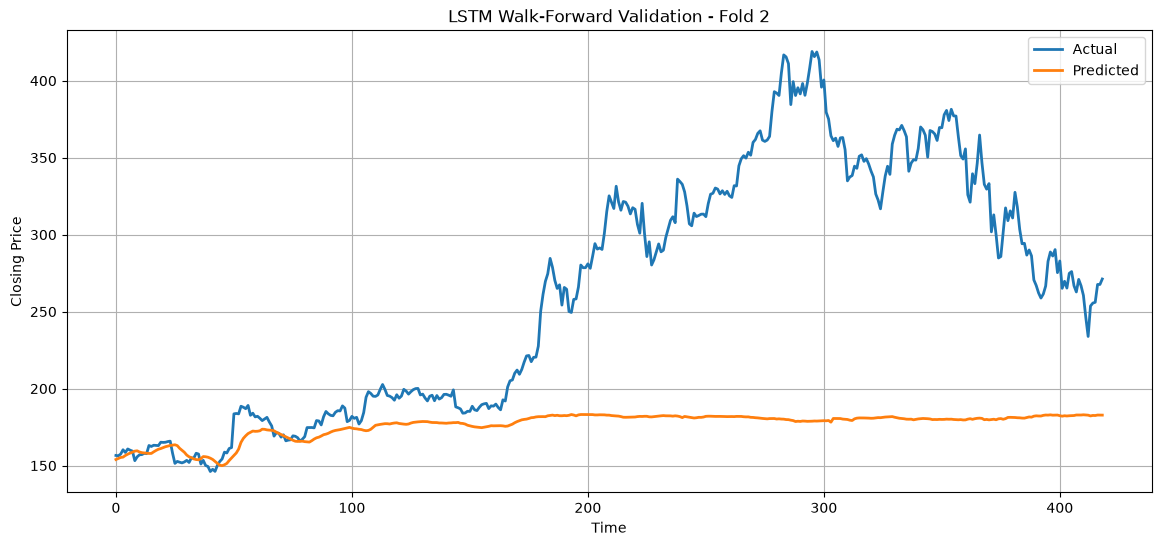

In [49]:
#plotting the actual and predicted fold 2

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(lstm_fold2_actual, label="Actual", linewidth = 2)
plt.plot(lstm_fold2_pred, label="Predicted", linewidth = 2)

plt.title("LSTM Walk-Forward Validation - Fold 2")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
[name for name in globals() if "rmse" in name.lower()]

['rmse_lr_random',
 'rmse_lr_time',
 'rmse_dt_random',
 'rmse_dt_time',
 'rmse_rf_random',
 'rmse_rf_time',
 'rmse_scores',
 'rmse_lr_wf',
 'lr_fold_rmse',
 'mean_rmse_lr_wf',
 'rmse_dt_wf',
 'dt_fold_rmse',
 'mean_rmse_dt_wf',
 'rmse_rf_wf',
 'rf_fold_rmse',
 'mean_rmse_rf_wf',
 'rmse_xgb_random',
 'rmse_xgb_time',
 'rmse_xgb_wf',
 'xgb_fold_rmse',
 'mean_rmse_xgb_wf',
 'rmse_mlp_random',
 'rmse_mlp_time',
 'rmse_mlp_wf',
 'mlp_fold_rmse',
 'mean_rmse_mlp_wf',
 'rmse_lstm_time',
 'rmse_lstm_eng_time',
 'rmse',
 'lstm_raw_fold_rmse',
 'mean_rmse_lstm_raw_wf']

### **Master Table**

In [51]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP",
        "Raw LSTM"
    ],

    "Random RMSE": [
        rmse_lr_random,
        rmse_dt_random,
        rmse_rf_random,
        rmse_xgb_random,
        rmse_mlp_random,
        np.nan
    ],

    "Time RMSE": [
        rmse_lr_time,
        rmse_dt_time,
        rmse_rf_time,
        rmse_xgb_time,
        rmse_mlp_time,
        rmse_lstm_time
    ],

    "Walk Mean RMSE": [
        mean_rmse_lr_wf,
        mean_rmse_dt_wf,
        mean_rmse_rf_wf,
        mean_rmse_xgb_wf,
        mean_rmse_mlp_wf,
        mean_rmse_lstm_raw_wf
    ],

    "Walk Median RMSE": [
        np.median(lr_fold_rmse),
        np.median(dt_fold_rmse),
        np.median(rf_fold_rmse),
        np.median(xgb_fold_rmse),
        np.median(mlp_fold_rmse),
        np.median(lstm_raw_fold_rmse)
    ],

    "Walk Forward rmse Std": [
        np.std(lr_fold_rmse),
        np.std(dt_fold_rmse),
        np.std(rf_fold_rmse),
        np.std(xgb_fold_rmse),
        np.std(mlp_fold_rmse),
        np.std(lstm_raw_fold_rmse)
    ]
})


# Best RMSE across the available validation methods
results["Best RMSE"] = results[
    [
        "Random RMSE",
        "Time RMSE",
        "Walk Mean RMSE"
    ]
].min(axis=1)


# Absolute increase in RMSE from random to walk-forward
results["RMSE Increase (Walk − Random)"] = (
    results["Walk Mean RMSE"]
    - results["Random RMSE"]
)


# Percentage increase relative to random validation
results["Validation Inflation (%)"] = (
    (
        results["Walk Mean RMSE"]
        - results["Random RMSE"]
    )
    / results["Random RMSE"]
) * 100


# How many times larger walk-forward RMSE is than random RMSE
results["Overestimation Ratio (Walk/Random)"] = (
    results["Walk Mean RMSE"]
    / results["Random RMSE"]
)


# Put columns in the exact order you want
results = results[
    [
        "Model",
        "Random RMSE",
        "Time RMSE",
        "Walk Mean RMSE",
        "Best RMSE",
        "Walk Median RMSE",
        "Walk Forward rmse Std",
        "RMSE Increase (Walk − Random)",
        "Validation Inflation (%)",
        "Overestimation Ratio (Walk/Random)"
    ]
]


# Round for cleaner display
results = results.round(2)

results

,Model,Random RMSE,Time RMSE,Walk Mean RMSE,Best RMSE,Walk Median RMSE,Walk Forward rmse Std,RMSE Increase (Walk − Random),Validation Inflation (%),Overestimation Ratio (Walk/Random)
0,Linear Regression,8.60,12.83,10.26,8.60,10.19,2.81,1.66,19.28,1.19
1,Decision Tree,12.77,29.23,53.94,12.77,48.05,43.79,41.17,322.47,4.22
2,Random Forest,9.13,16.81,48.66,9.13,36.95,44.70,39.53,433.09,5.33
3,XGBoost,9.42,23.07,51.97,9.42,44.27,43.94,42.54,451.43,5.51
4,MLP,9.12,30.58,26.10,9.12,25.62,13.45,16.98,186.20,2.86
5,Raw LSTM,NaN,19.17,38.23,19.17,17.48,38.43,NaN,NaN,NaN


###### The Netflix results demonstrate substantial differences in estimated forecasting performance across validation strategies. For every model evaluated under both random and walk-forward approaches, random splitting produced a lower RMSE. However, the magnitude of this difference varied considerably across models. Linear Regression exhibited only a 19.3% increase in RMSE from random to walk-forward evaluation, whereas Decision Tree, Random Forest, and XGBoost exhibited increases exceeding 300%. MLP showed an intermediate increase of approximately 186%. Walk-forward variability also differed substantially across models, with Linear Regression exhibiting the lowest fold-to-fold RMSE standard deviation.
###### The large differences between walk-forward mean and median RMSE for several models indicate that poor performance was concentrated in particular temporal periods rather than being uniformly distributed across all folds. This is especially apparent for the tree-based models and the raw LSTM, where individual high-error folds substantially increased mean RMSE.

### **Figure 1: Comparison of RMSE Across Validation Strategies**

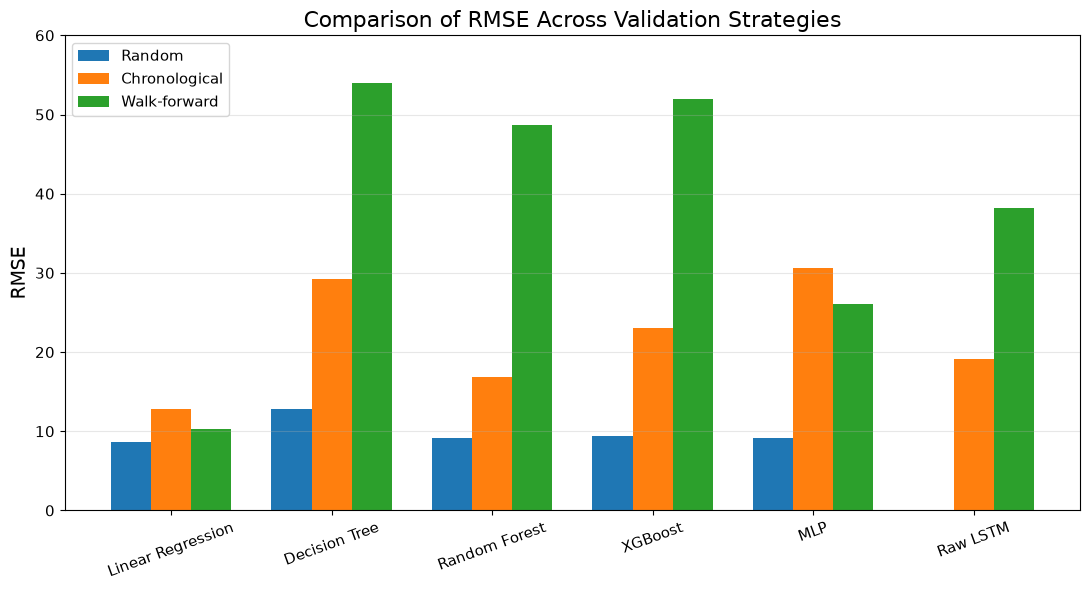

In [52]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    results["Random RMSE"],
    width,
    label="Random"
)

plt.bar(
    x,
    results["Time RMSE"],
    width,
    label="Chronological"
)

plt.bar(
    x + width,
    results["Walk Mean RMSE"],
    width,
    label="Walk-forward"
)

plt.xticks(
    x,
    results["Model"],
    rotation=20,
    fontsize=11
)

plt.yticks(fontsize=11)

plt.ylabel(
    "RMSE",
    fontsize=14
)

plt.title(
    "Comparison of RMSE Across Validation Strategies",
    fontsize=16
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.ylim(0, 60)

plt.legend(
    fontsize=11
)

plt.tight_layout()

plt.show()

### **Figure 2: Increase in RMSE from Random to Walk-Forward Validation**

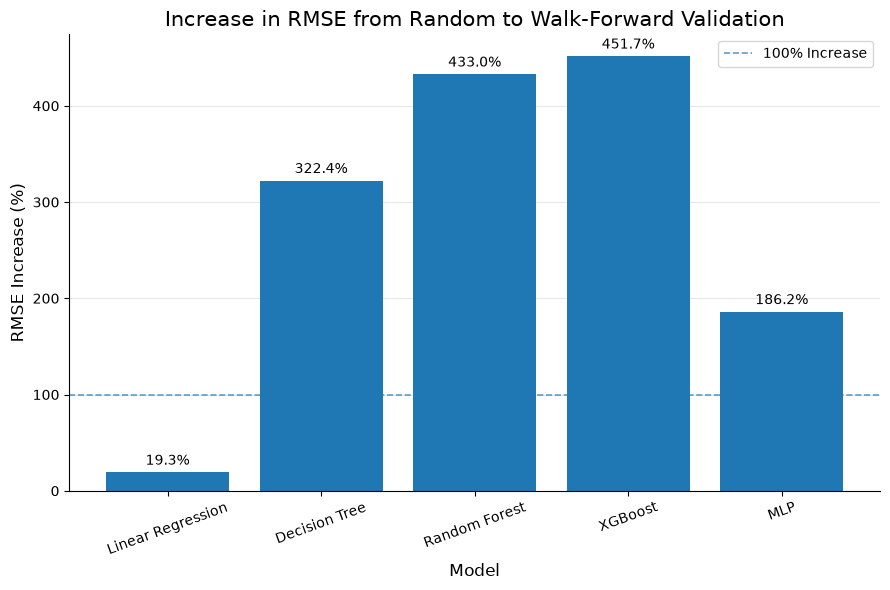

In [53]:
import matplotlib.pyplot as plt

# Calculate percentage increase from random to walk-forward validation
results["Validation Inflation (%)"] = (
    (
        results["Walk Mean RMSE"]
        - results["Random RMSE"]
    )
    / results["Random RMSE"]
) * 100

# Exclude models without a random-split result, such as Raw LSTM
plot_data = results.dropna(
    subset=["Validation Inflation (%)"]
).copy()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    plot_data["Model"],
    plot_data["Validation Inflation (%)"]
)

ax.set_title(
    "Increase in RMSE from Random to Walk-Forward Validation",
    fontsize=15
)

ax.set_xlabel(
    "Model",
    fontsize=12
)

ax.set_ylabel(
    "RMSE Increase (%)",
    fontsize=12
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelrotation=20,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_data["Validation Inflation (%)"]
    ],
    padding=3,
    fontsize=10
)

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="100% Increase"
)

ax.legend()

plt.tight_layout()
plt.show()

###### Relative increase in RMSE when models are evaluated using walk-forward validation instead of random train-test splitting on the Netflix dataset. Tree-based models exhibit substantial inflation in prediction error (322–451%), whereas Linear Regression remains comparatively stable (19%), suggesting that random validation disproportionately overestimates the performance of more complex nonlinear models.

In [54]:
walk_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Linear": lr_fold_rmse,
    "Decision Tree": dt_fold_rmse,
    "Random Forest": rf_fold_rmse,
    "XGBoost": xgb_fold_rmse,
    "MLP": mlp_fold_rmse,
    "Raw LSTM": lstm_raw_fold_rmse
})

walk_df

,Fold,Linear,Decision Tree,Random Forest,XGBoost,MLP,Raw LSTM
0,1,6.381539,12.797803,13.468279,16.518285,26.281803,12.152730
1,2,10.189660,133.537805,133.315793,134.148407,50.756062,113.972708
2,3,10.373939,48.054993,36.949904,44.272708,13.744667,17.482276
3,4,15.093507,59.950188,48.925503,52.700061,25.619568,31.406022
4,5,9.266049,15.359712,10.619845,12.187787,14.097681,16.120844


### **Figure 3: Walk-forward Performance Across Folds**

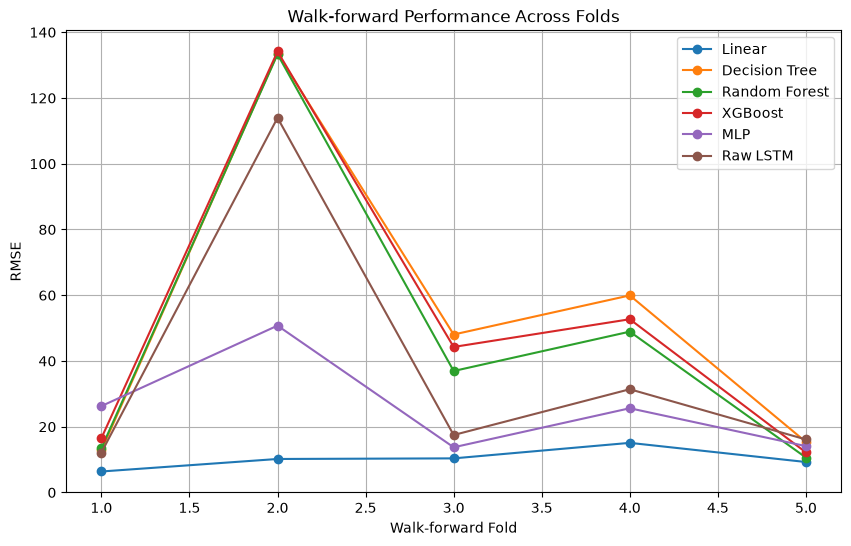

In [55]:
plt.figure(figsize=(10,6))

for col in walk_df.columns[1:]:
    plt.plot(
        walk_df["Fold"],
        walk_df[col],
        marker="o",
        label=col
    )

plt.xlabel("Walk-forward Fold")
plt.ylabel("RMSE")
plt.title("Walk-forward Performance Across Folds")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build Netflix walk-forward results directly from existing variables
netflix_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP",
        "Raw LSTM"
    ],

    "Walk-Forward Mean RMSE": [
        np.mean(lr_fold_rmse),
        np.mean(dt_fold_rmse),
        np.mean(rf_fold_rmse),
        np.mean(xgb_fold_rmse),
        np.mean(mlp_fold_rmse),
        np.mean(lstm_raw_fold_rmse)
    ],

    "Walk-Forward RMSE Std": [
        np.std(lr_fold_rmse),
        np.std(dt_fold_rmse),
        np.std(rf_fold_rmse),
        np.std(xgb_fold_rmse),
        np.std(mlp_fold_rmse),
        np.std(lstm_raw_fold_rmse)
    ]
})

print(netflix_results)

               Model  Walk-Forward Mean RMSE  Walk-Forward RMSE Std
0  Linear Regression               10.260939               2.807529
1      Decision Tree               53.940100              43.789691
2      Random Forest               48.655865              44.697451
3            XGBoost               51.965450              43.937502
4                MLP               26.099956              13.452845
5           Raw LSTM               38.226916              38.426114


### **Figure 4: Walk-Forward RMSE and Fold-to-Fold Variability Across Models**

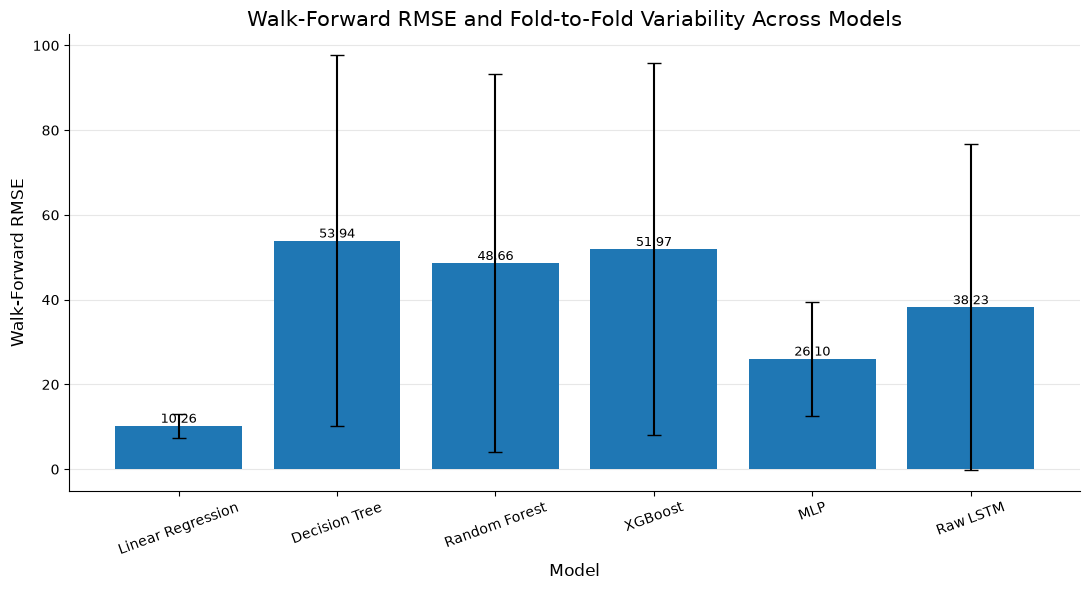

In [57]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    netflix_results["Model"],
    netflix_results["Walk-Forward Mean RMSE"],
    yerr=netflix_results["Walk-Forward RMSE Std"],
    capsize=5
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Walk-Forward RMSE", fontsize=12)

ax.set_title(
    "Walk-Forward RMSE and Fold-to-Fold Variability Across Models",
    fontsize=15
)

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add mean RMSE above each bar
for bar, value in zip(
    bars,
    netflix_results["Walk-Forward Mean RMSE"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

###### Random validation can hide not only higher future prediction error, but also how unstable model performance is across different market periods.

### **Figure 5: Model Predictions During a High-Shift Walk-Forward Test Period (Fold 2)**

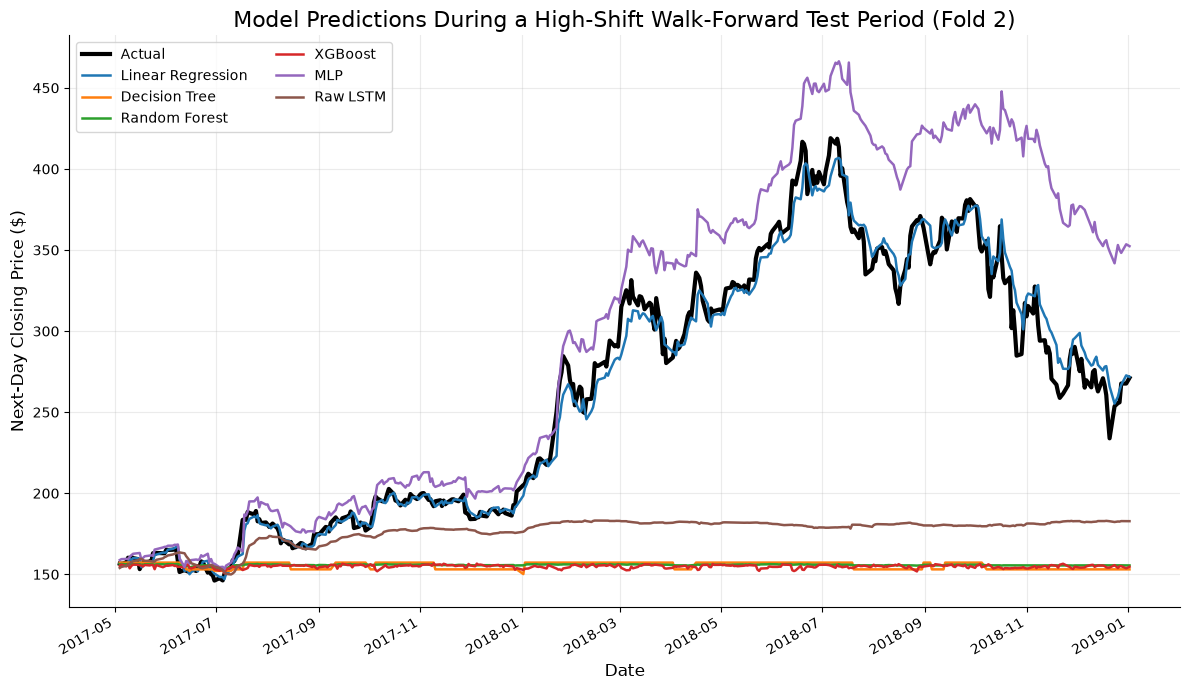

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# Actual stock price
ax.plot(
    lr_fold2_dates,
    lr_fold2_actual,
    label="Actual",
    linewidth=3,
    color="black"
)

# Linear Regression
ax.plot(
    lr_fold2_dates,
    lr_fold2_pred,
    label="Linear Regression",
    linewidth=1.8
)

# Decision Tree
ax.plot(
    dt_fold2_dates,
    dt_fold2_pred,
    label="Decision Tree",
    linewidth=1.8
)

# Random Forest
ax.plot(
    rf_fold2_dates,
    rf_fold2_pred,
    label="Random Forest",
    linewidth=1.8
)

# XGBoost
ax.plot(
    xgb_fold2_dates,
    xgb_fold2_pred,
    label="XGBoost",
    linewidth=1.8
)

# MLP
ax.plot(
    mlp_fold2_dates,
    mlp_fold2_pred,
    label="MLP",
    linewidth=1.8
)

# Raw LSTM
ax.plot(
    lstm_fold2_dates,
    lstm_fold2_pred,
    label="Raw LSTM",
    linewidth=1.8
)

ax.set_title(
    "Model Predictions During a High-Shift Walk-Forward Test Period (Fold 2)",
    fontsize=16
)

ax.set_xlabel(
    "Date",
    fontsize=12
)

ax.set_ylabel(
    "Next-Day Closing Price ($)",
    fontsize=12
)

ax.grid(
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=10,
    ncol=2
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

###### Fold 2 illustrates the period-specific behavior observed in the walk-forward analysis. During this test period, actual Netflix prices increased substantially beyond levels represented in the preceding training history. Decision Tree, Random Forest, and XGBoost predictions remained concentrated near earlier price levels, corresponding with their large Fold 2 RMSE values. Linear Regression tracked the changing price level more closely, while MLP substantially overshot the observed prices. The raw LSTM adjusted upward but did not capture the full magnitude of the price movement. This example demonstrates how aggregate validation scores can obscure substantially different model behavior during individual future periods.

In [59]:
ranking_results = results[
    results["Random RMSE"].notna()
].copy()

ranking_results["Random Rank"] = (
    ranking_results["Random RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking_results["Walk Rank"] = (
    ranking_results["Walk Mean RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking_results[
    [
        "Model",
        "Random RMSE",
        "Random Rank",
        "Walk Mean RMSE",
        "Walk Rank"
    ]
]

,Model,Random RMSE,Random Rank,Walk Mean RMSE,Walk Rank
0,Linear Regression,8.60,1,10.26,1
1,Decision Tree,12.77,5,53.94,5
2,Random Forest,9.13,3,48.66,3
3,XGBoost,9.42,4,51.97,4
4,MLP,9.12,2,26.10,2


In [60]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    ranking_results["Random Rank"],
    ranking_results["Walk Rank"]
)

print("Spearman rank correlation:", rho)
print("p-value:", p_value)

Spearman rank correlation: 0.9999999999999999
p-value: 1.4042654220543608e-24


In [61]:
netflix_results = results.copy()

netflix_results.to_csv(
    "../outputs/netflix_results.csv",
    index=False
)

In [62]:
import pandas as pd
import numpy as np

fold_results = {
    "Linear Regression": lr_fold_rmse,
    "Decision Tree": dt_fold_rmse,
    "Random Forest": rf_fold_rmse,
    "XGBoost": xgb_fold_rmse,
    "MLP": mlp_fold_rmse,
    "Raw LSTM": lstm_raw_fold_rmse
}

period_analysis = []

for model, scores in fold_results.items():

    scores = np.array(scores)

    worst_fold = np.argmax(scores) + 1
    worst_rmse = np.max(scores)

    mean_all = np.mean(scores)

    scores_without_worst = np.delete(
        scores,
        np.argmax(scores)
    )

    mean_without_worst = np.mean(
        scores_without_worst
    )

    worst_contribution = (
        worst_rmse / np.sum(scores)
    ) * 100

    period_analysis.append({
        "Model": model,
        "Worst Fold": worst_fold,
        "Worst Fold RMSE": worst_rmse,
        "Mean RMSE": mean_all,
        "Mean Without Worst Fold": mean_without_worst,
        "Worst Fold Contribution (%)": worst_contribution
    })

period_analysis = pd.DataFrame(period_analysis)

period_analysis.round(2)

,Model,Worst Fold,Worst Fold RMSE,Mean RMSE,Mean Without Worst Fold,Worst Fold Contribution (%)
0,Linear Regression,4,15.09,10.26,9.05,29.42
1,Decision Tree,2,133.54,53.94,34.04,49.51
2,Random Forest,2,133.32,48.66,27.49,54.80
3,XGBoost,2,134.15,51.97,31.42,51.63
4,MLP,2,50.76,26.10,19.94,38.89
5,Raw LSTM,2,113.97,38.23,19.29,59.63


###### Walk-forward errors on Netflix were strongly concentrated in specific temporal periods. Fold 2 was the highest-error fold for Decision Tree, Random Forest, XGBoost, MLP, and the raw LSTM. For Random Forest, XGBoost, and LSTM, this single fold accounted for more than half of the sum of RMSE values across the five folds. Removing the worst fold reduced mean RMSE from 48.66 to 27.49 for Random Forest, from 51.97 to 31.42 for XGBoost, and from 38.23 to 19.29 for the raw LSTM. Linear Regression showed a different pattern: its worst period occurred in Fold 4 and removing it reduced mean RMSE only from 10.26 to 9.05. These results indicate that walk-forward evaluation exposes substantial period-specific forecasting failures that would be obscured by a single aggregate performance estimate.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

shift_rows = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    train_min = y_train_fold.min()
    train_max = y_train_fold.max()

    test_min = y_test_fold.min()
    test_max = y_test_fold.max()

    # Test observations above anything seen during training
    above_train_max = (y_test_fold > train_max)

    # Test observations below anything seen during training
    below_train_min = (y_test_fold < train_min)

    outside_range = above_train_max | below_train_min

    shift_rows.append({
        "Fold": fold,

        "Train Min": train_min,
        "Train Max": train_max,

        "Test Min": test_min, test_max_train_min
        "Test Max": test_max,

        "Test Above Train Max (%)":
            above_train_max.mean() * 100,

        "Test Below Train Min (%)":
            below_train_min.mean() * 100,

        "Test Outside Train Range (%)":
            outside_range.mean() * 100,

        "Upper Range Extension":
            max(0, test_max - train_max),

        "Lower Range Extension":
            max(0, train_min - test_min)
    })

shift_analysis = pd.DataFrame(shift_rows)

shift_analysis.round(2)

,Fold,Train Min,Train Max,Test Min,Test Max,Test Above Train Max (%),Test Below Train Min (%),Test Outside Train Range (%),Upper Range Extension,Lower Range Extension
0,1,44.89,126.45,82.79,157.25,23.15,0.0,23.15,30.80,0
1,2,44.89,157.25,146.17,418.97,94.03,0.0,94.03,261.72,0
2,3,44.89,418.97,254.59,556.55,21.72,0.0,21.72,137.58,0
3,4,44.89,556.55,188.54,691.69,23.87,0.0,23.87,135.14,0
4,5,44.89,691.69,166.37,495.02,0.00,0.0,0.00,0.00,0


###### Target-range analysis provides additional context for the unusually poor performance observed during Netflix Fold 2. Prior to this test period, the expanding training data contained target prices between $44.89 and $157.25, whereas Fold 2 contained prices between $146.17 and $418.97. Approximately 94.03% of Fold 2 targets exceeded the maximum target value observed during training, and the test maximum extended $261.72 beyond the previous training maximum. This coincided with the highest RMSE fold for five of the six evaluated models. In contrast, by Fold 5 the expanding training history covered the entire test target range, with 0% of observations outside the historical range, and substantially lower errors were observed across models. These results suggest that the severe Fold 2 errors coincided with an unusually large target-range shift, although target-range extrapolation alone does not fully explain performance differences across all folds.

In [64]:
shift_analysis["LR RMSE"] = lr_fold_rmse
shift_analysis["DT RMSE"] = dt_fold_rmse
shift_analysis["RF RMSE"] = rf_fold_rmse
shift_analysis["XGB RMSE"] = xgb_fold_rmse
shift_analysis["MLP RMSE"] = mlp_fold_rmse
shift_analysis["LSTM RMSE"] = lstm_raw_fold_rmse

shift_analysis.round(2)

,Fold,Train Min,Train Max,Test Min,Test Max,Test Above Train Max (%),Test Below Train Min (%),Test Outside Train Range (%),Upper Range Extension,Lower Range Extension,LR RMSE,DT RMSE,RF RMSE,XGB RMSE,MLP RMSE,LSTM RMSE
0,1,44.89,126.45,82.79,157.25,23.15,0.0,23.15,30.80,0,6.38,12.80,13.47,16.52,26.28,12.15
1,2,44.89,157.25,146.17,418.97,94.03,0.0,94.03,261.72,0,10.19,133.54,133.32,134.15,50.76,113.97
2,3,44.89,418.97,254.59,556.55,21.72,0.0,21.72,137.58,0,10.37,48.05,36.95,44.27,13.74,17.48
3,4,44.89,556.55,188.54,691.69,23.87,0.0,23.87,135.14,0,15.09,59.95,48.93,52.70,25.62,31.41
4,5,44.89,691.69,166.37,495.02,0.00,0.0,0.00,0.00,0,9.27,15.36,10.62,12.19,14.10,16.12


###### The fold-level target-range analysis showed a strong descriptive association between extreme target-range extrapolation and forecasting failure during Netflix Fold 2. Approximately 94.03% of Fold 2 targets exceeded the maximum target observed during training, and the future maximum extended $261.72 beyond the historical training maximum. This period coincided with the largest RMSE for Decision Tree, Random Forest, XGBoost, MLP, and the raw LSTM. However, Linear Regression remained comparatively accurate during the same period, and folds with similar range-extension characteristics sometimes produced different error levels. Target-range shift therefore appears to be an important characteristic of difficult forecasting periods in this experiment, but it does not by itself explain model performance.